In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Sequence

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import BaseEstimatorV2
from qiskit.circuit.library import XGate
from qiskit.circuit.library import efficient_su2
from dyn_esu2 import dynamic_esu2
from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes.scheduling import (
    ALAPScheduleAnalysis,
    PadDynamicalDecoupling,
)

from qiskit.primitives import StatevectorEstimator
from qiskit_aer.primitives import EstimatorV2
# from qiskit_ibm_runtime import QiskitRuntimeService, Session, EstimatorV2
from qiskit_ibm_runtime.fake_provider import FakeFractionalBackend, FakeGuadalupeV2

from itertools import product

import warnings
warnings.filterwarnings("ignore")

In [2]:
from hamlib_snippets import get_hdf5_keys, read_qiskit_hdf5
keys = get_hdf5_keys('heis.hdf5')
# print(keys)

In [3]:
num_sites = [3, 5, 10]
couplings = [0, 0.1, 0.5, 1, 2, 3, 5]

hamiltonians = dict()
for n, h in product(num_sites, couplings) :
    hamiltonian = read_qiskit_hdf5('heis.hdf5', f'graph-1D-grid-nonpbc-qubitnodes_Lx-{n}_h-{h}')
    hamiltonians[(n, h)] = hamiltonian
    print(n, h, hamiltonian)

3 0 SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])
3 0.1 SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ', 'ZII', 'IZI', 'IIZ'],
              coeffs=[1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 0.1+0.j, 0.1+0.j,
 0.1+0.j])
3 0.5 SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ', 'ZII', 'IZI', 'IIZ'],
              coeffs=[1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 0.5+0.j, 0.5+0.j,
 0.5+0.j])
3 1 SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ', 'ZII', 'IZI', 'IIZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])
3 2 SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ', 'ZII', 'IZI', 'IIZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 2.+0.j, 2.+0.j, 2.+0.j])
3 3 SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ', 'ZII', 'IZI', 'IIZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.

In [4]:
n, h = 3, 0
base_hamiltonian = hamiltonians[(n, h)]
Id = SparsePauliOp.from_sparse_list([('I'*(n-1), list(range(n-1)), 1)], num_qubits=n-1)
hamiltonian = Id ^ base_hamiltonian
print(hamiltonian)

SparsePauliOp(['IIXXI', 'IIYYI', 'IIZZI', 'IIIXX', 'IIIYY', 'IIIZZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


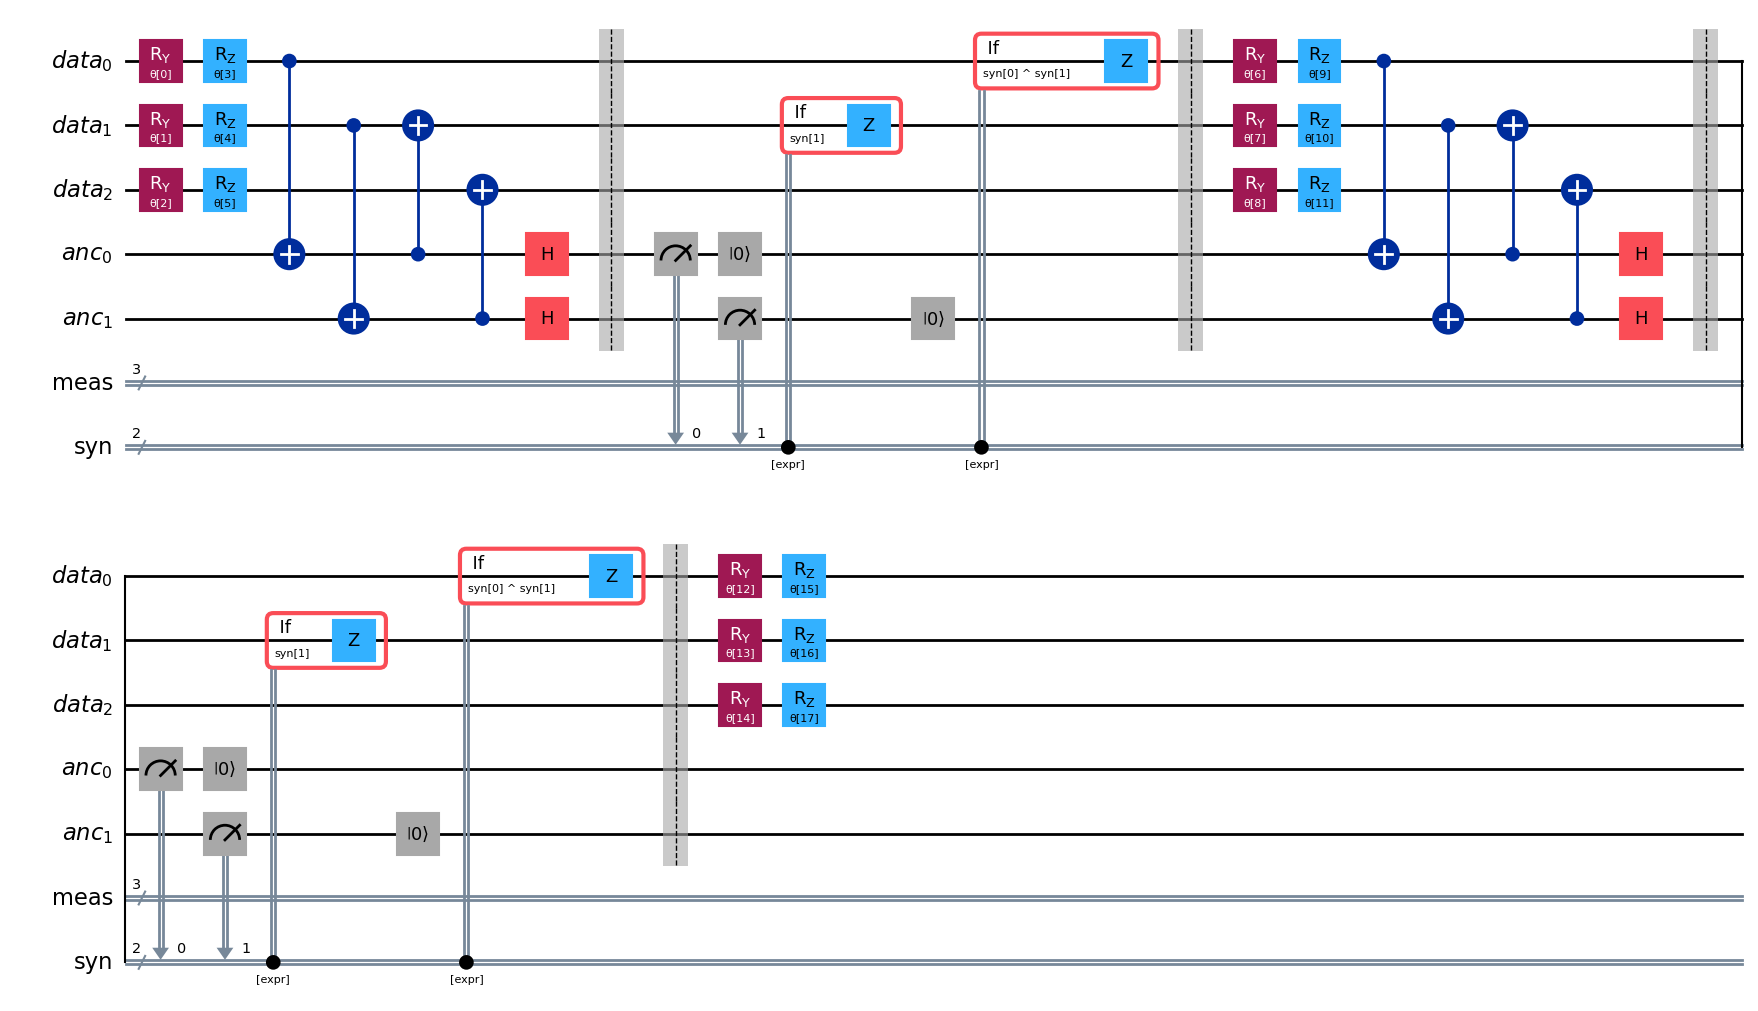

In [5]:
ansatz = dynamic_esu2(n=n, d=2, mcm=False)

ansatz.draw("mpl", style="iqp")

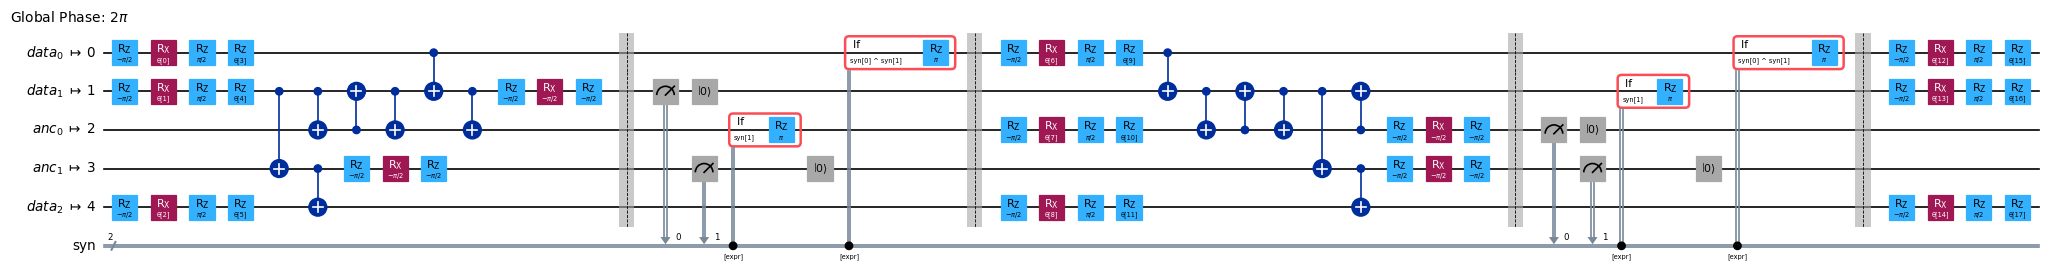

In [6]:
backend = FakeFractionalBackend()
target = backend.target
pm = generate_preset_pass_manager(optimization_level=3, target=target)
isa_ansatz = pm.run(ansatz)
isa_observable = hamiltonian.apply_layout(isa_ansatz.layout)
isa_ansatz.draw("mpl", scale=0.6, style="iqp", fold=-1, idle_wires=False)

In [7]:
with open(f'params/params_{n}_{h}.npy', 'rb') as f :
    opt_params = np.load(f)
print(opt_params)

[ 2.76621847  6.88626253  4.53389364  3.61417427  0.91833437  1.05984442
 -0.36823476  6.29423043  3.73668303  4.41575212  0.51459513  5.88607675
  5.87064047  1.17470334  0.92233634  0.7619072   1.95492639  3.55743742]


In [8]:
for i in range(3) :
    estimator = EstimatorV2()
    estimator.skip_transpilation = True
    energy = (
            estimator.run([(isa_ansatz, isa_observable, [opt_params])]).result()[0].data.evs
        )
    print(energy)

[-1.91026095]
[-1.91026095]
[-1.91026095]
